<!-- config-banner -->
# DINO 1° — increased grid viscosity

**`viscGrid1p135e-2`** — same comparison as `01`, with `viscAhGrid` raised from `1.0E-2` to `1.135E-2`. Run 28402 (reference `PARM05` files) vs run 28448.


In [1]:
import numpy as np
import xarray as xr
from pathlib import Path
import glob
import xmitgcm

import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings("ignore")

## Loading the Data

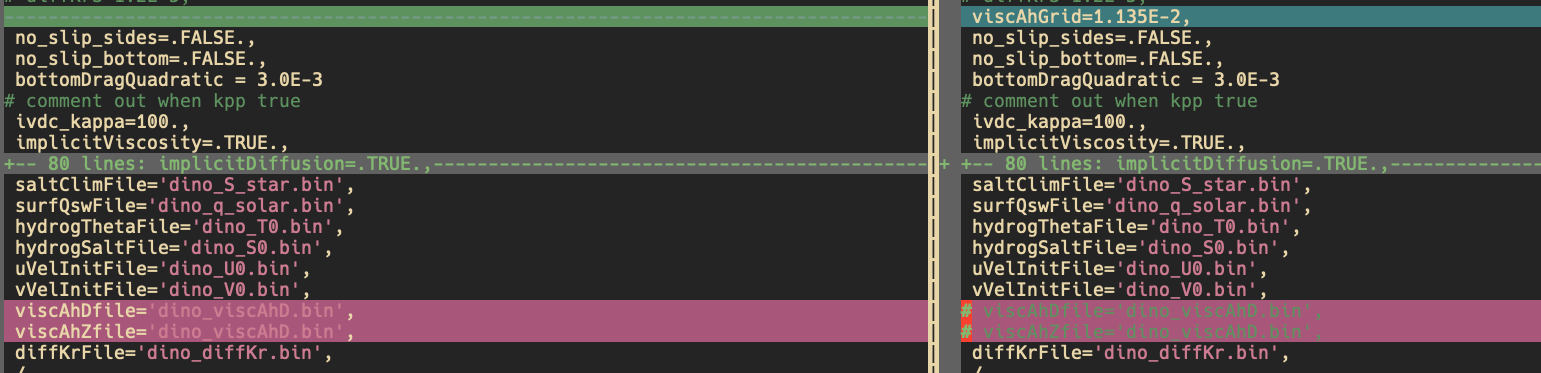

In [2]:
# -------------------------------
# User inputs
# -------------------------------
# Not using viscAhGrid; viscAhDfile='dino_viscAhD.bin' and viscAhZfile='dino_viscAhD.bin' are both ON
run_dir = Path("/scratch2/tshahriar/DINO_1deg_frd_runs/runs_exploratory/DINO_1deg_frd_1yr_from_rest_viscRef_run28402/") 

# using viscAhGrid=0.01 and viscAhDfile and viscAhZfile both are OFF
run_dir_viscAhGrid = Path("/scratch2/tshahriar/DINO_1deg_frd_runs/runs_exploratory/DINO_1deg_frd_1yr_from_rest_viscGrid1p135e-2_run28448/") 

grid_dir = run_dir  # change if your grid files live elsewhere

ref = np.datetime64("2000-01-01T00:00:00")
delta_t = 1800.0

In [3]:
# iters = sorted([int(p.name.split(".")[-2]) for p in run_dir.glob("viscDiag.*.meta")])
# # iters

In [4]:
# iters[-1]

In [5]:
# -----------------------
# 1) Load ONE viscDiag timestep with xmitgcm
# -----------------------
iters = sorted([int(p.name.split(".")[-2]) for p in run_dir.glob("viscDiag.*.meta")])
it = iters[-1]  # last available
ds = xmitgcm.open_mdsdataset(
    data_dir=str(run_dir),
    grid_dir=str(grid_dir),
    prefix=["viscDiag"],
    geometry="curvilinear",
    iters=[it],
    delta_t=delta_t,
    ref_date=ref,
)

In [6]:
ds

<xarray.Dataset>
Dimensions:  (i: 51, i_g: 51, j: 198, j_g: 198, k: 36, k_u: 36, k_l: 36,
              k_p1: 37, time: 1)
Coordinates: (12/44)
  * i        (i) int64 0 1 2 3 4 5 6 7 8 9 10 ... 41 42 43 44 45 46 47 48 49 50
  * i_g      (i_g) int64 0 1 2 3 4 5 6 7 8 9 ... 41 42 43 44 45 46 47 48 49 50
  * j        (j) int64 0 1 2 3 4 5 6 7 8 ... 189 190 191 192 193 194 195 196 197
  * j_g      (j_g) int64 0 1 2 3 4 5 6 7 8 ... 190 191 192 193 194 195 196 197
  * k        (k) int64 0 1 2 3 4 5 6 7 8 9 10 ... 26 27 28 29 30 31 32 33 34 35
  * k_u      (k_u) int64 0 1 2 3 4 5 6 7 8 9 ... 26 27 28 29 30 31 32 33 34 35
    ...       ...
    maskS    (k, j_g, i) bool dask.array<chunksize=(36, 198, 51), meta=np.ndarray>
    rhoRef   (k) >f4 1.024e+03 1.024e+03 1.024e+03 ... 1.045e+03 1.048e+03
    dxF      (j, i) >f4 dask.array<chunksize=(198, 51), meta=np.ndarray>
    dyF      (j, i) >f4 dask.array<chunksize=(198, 51), meta=np.ndarray>
    dxV      (j_g, i_g) >f4 dask.array<chunksize=(198, 51), meta=np.ndarray>
    dyU      (j_g, i_g) >f4 dask.array<chunksize=(198, 51), meta=np.ndarray>
Data variables:
    VISCAHZ  (time, k, j_g, i_g) >f4 dask.array<chunksize=(1, 36, 198, 51), meta=np.ndarray>
    VISCAHD  (time, k, j, i) >f4 dask.array<chunksize=(1, 36, 198, 51), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6
    title:        netCDF wrapper of MITgcm MDS binary data
    source:       MITgcm
    history:      Created by calling `open_mdsdataset(grid_dir='/scratch2/tsh...

In [7]:
# iters_viscAhGrid = sorted([int(p.name.split(".")[-2]) for p in run_dir_viscAhGrid.glob("viscDiag.*.meta")])
# it_viscAhGrid = iters_viscAhGrid[-1]  # last available
# it_viscAhGrid

In [8]:
# -----------------------
# 1) Load ONE viscDiag timestep with xmitgcm
# -----------------------
iters_viscAhGrid = sorted([int(p.name.split(".")[-2]) for p in run_dir_viscAhGrid.glob("viscDiag.*.meta")])
it_viscAhGrid = iters_viscAhGrid[-1]  # last available
ds_viscAhGrid = xmitgcm.open_mdsdataset(
    data_dir=str(run_dir_viscAhGrid),
    grid_dir=str(grid_dir),
    prefix=["viscDiag"],
    geometry="curvilinear",
    iters=[it_viscAhGrid],
    delta_t=delta_t,
    ref_date=ref,
)

In [9]:
ds_viscAhGrid

<xarray.Dataset>
Dimensions:  (i: 51, i_g: 51, j: 198, j_g: 198, k: 36, k_u: 36, k_l: 36,
              k_p1: 37, time: 1)
Coordinates: (12/44)
  * i        (i) int64 0 1 2 3 4 5 6 7 8 9 10 ... 41 42 43 44 45 46 47 48 49 50
  * i_g      (i_g) int64 0 1 2 3 4 5 6 7 8 9 ... 41 42 43 44 45 46 47 48 49 50
  * j        (j) int64 0 1 2 3 4 5 6 7 8 ... 189 190 191 192 193 194 195 196 197
  * j_g      (j_g) int64 0 1 2 3 4 5 6 7 8 ... 190 191 192 193 194 195 196 197
  * k        (k) int64 0 1 2 3 4 5 6 7 8 9 10 ... 26 27 28 29 30 31 32 33 34 35
  * k_u      (k_u) int64 0 1 2 3 4 5 6 7 8 9 ... 26 27 28 29 30 31 32 33 34 35
    ...       ...
    maskS    (k, j_g, i) bool dask.array<chunksize=(36, 198, 51), meta=np.ndarray>
    rhoRef   (k) >f4 1.024e+03 1.024e+03 1.024e+03 ... 1.045e+03 1.048e+03
    dxF      (j, i) >f4 dask.array<chunksize=(198, 51), meta=np.ndarray>
    dyF      (j, i) >f4 dask.array<chunksize=(198, 51), meta=np.ndarray>
    dxV      (j_g, i_g) >f4 dask.array<chunksize=(198, 51), meta=np.ndarray>
    dyU      (j_g, i_g) >f4 dask.array<chunksize=(198, 51), meta=np.ndarray>
Data variables:
    VISCAHZ  (time, k, j_g, i_g) >f4 dask.array<chunksize=(1, 36, 198, 51), meta=np.ndarray>
    VISCAHD  (time, k, j, i) >f4 dask.array<chunksize=(1, 36, 198, 51), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6
    title:        netCDF wrapper of MITgcm MDS binary data
    source:       MITgcm
    history:      Created by calling `open_mdsdataset(grid_dir='/scratch2/tsh...

## Comapring VISCAHD and VISCAHZ of the The Run Where viscAh*file is Used

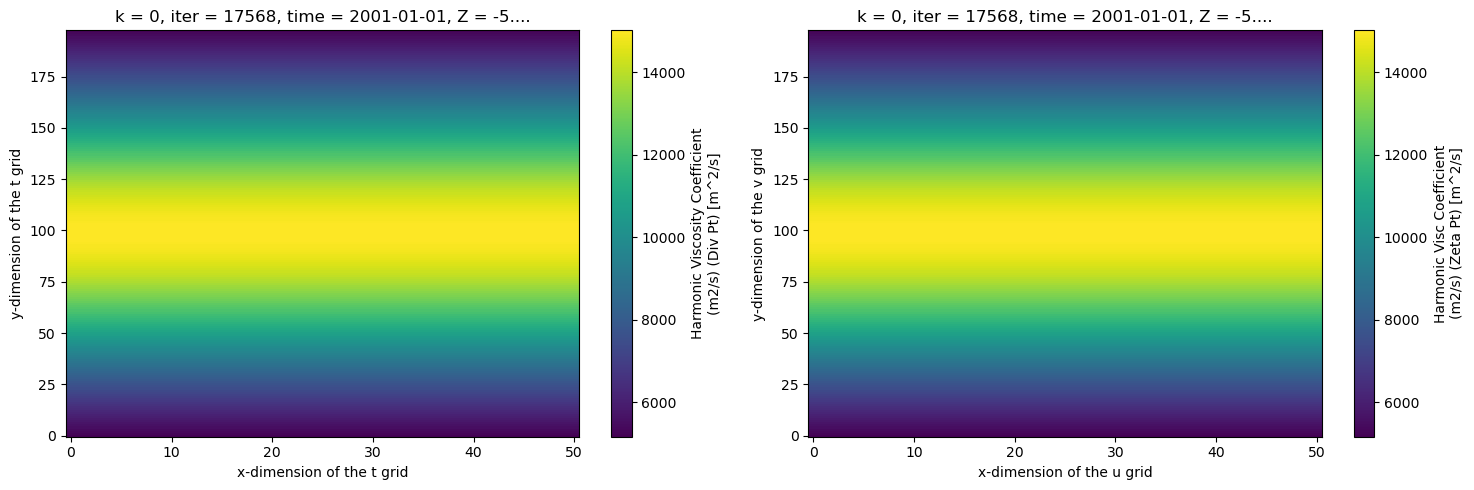

In [10]:
vmin = min(ds.VISCAHD[0,0].min().compute(), ds.VISCAHZ[0,0].min().compute())
vmax = max(ds.VISCAHD[0,0].max().compute(), ds.VISCAHZ[0,0].max().compute())

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ds.VISCAHD[0,0].plot(ax=ax[0], vmin=vmin, vmax=vmax)
ds.VISCAHZ[0,0].plot(ax=ax[1], vmin=vmin, vmax=vmax)

plt.tight_layout()
plt.show()

In [11]:
m1 = ds.VISCAHD[0,0].mean().compute().item()
m2 = ds.VISCAHZ[0,0].mean().compute().item()
md = (ds.VISCAHD[0,0] - ds.VISCAHZ[0,0]).mean().compute().item()

print(f"Domain mean VISCAHD        = {m1}")
print(f"Domain mean VISCAHZ        = {m2}")
print(f"Mean difference (D - Z)    = {md}")

Domain mean VISCAHD        = 10591.8896484375
Domain mean VISCAHZ        = 10591.8896484375
Mean difference (D - Z)    = -0.0005038364324718714


## Comapring VISCAHD and VISCAHZ of the The Run Where viscAhGrid is Used

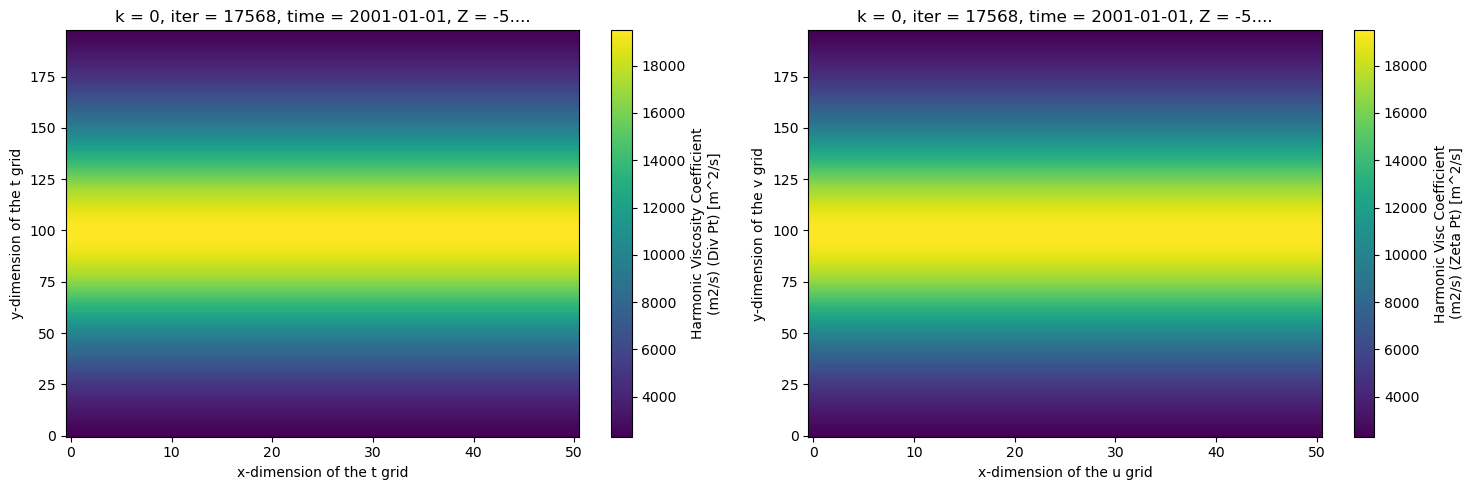

In [12]:
vmin = min(ds_viscAhGrid.VISCAHD[0,0].min().compute(), ds_viscAhGrid.VISCAHZ[0,0].min().compute())
vmax = max(ds_viscAhGrid.VISCAHD[0,0].max().compute(), ds_viscAhGrid.VISCAHZ[0,0].max().compute())

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ds_viscAhGrid.VISCAHD[0,0].plot(ax=ax[0], vmin=vmin, vmax=vmax)
ds_viscAhGrid.VISCAHZ[0,0].plot(ax=ax[1], vmin=vmin, vmax=vmax)

plt.tight_layout()
plt.show()

In [13]:
m1 = ds_viscAhGrid.VISCAHD[0,0].mean().compute().item()
m2 = ds_viscAhGrid.VISCAHZ[0,0].mean().compute().item()
md = (ds_viscAhGrid.VISCAHD[0,0] - ds_viscAhGrid.VISCAHZ[0,0]).mean().compute().item()

print(f"Domain mean VISCAHD        = {m1}")
print(f"Domain mean VISCAHZ        = {m2}")
print(f"Mean difference (D - Z)    = {md}")

Domain mean VISCAHD        = 10590.6962890625
Domain mean VISCAHZ        = 10590.7900390625
Mean difference (D - Z)    = -0.09637248516082764


## Comapring VISCAHD between the The Run Where viscAh*file is Used and Where viscAhGrid is Used

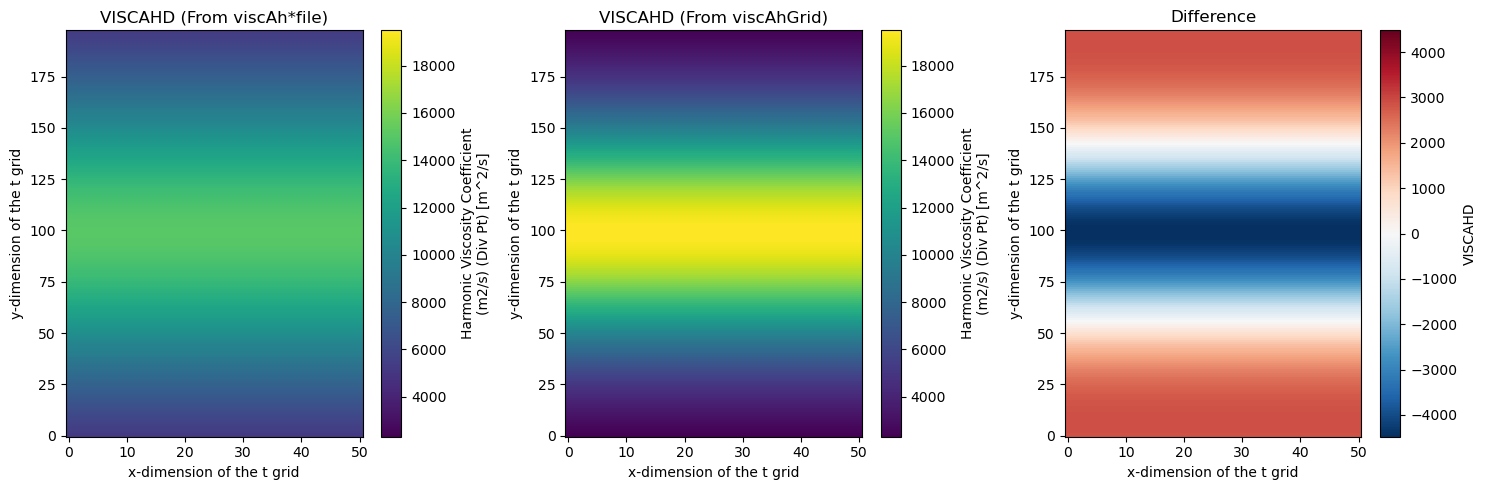

In [14]:
vmin = min(ds.VISCAHD[0,0].min().compute(), ds_viscAhGrid.VISCAHD[0,0].min().compute())
vmax = max(ds.VISCAHD[0,0].max().compute(), ds_viscAhGrid.VISCAHD[0,0].max().compute())

fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ds.VISCAHD[0,0].plot(ax=ax[0], vmin=vmin, vmax=vmax)
ax[0].set_title("VISCAHD (From viscAh*file)")

ds_viscAhGrid.VISCAHD[0,0].plot(ax=ax[1], vmin=vmin, vmax=vmax)
ax[1].set_title("VISCAHD (From viscAhGrid)")

(ds.VISCAHD[0,0] - ds_viscAhGrid.VISCAHD[0,0]).plot(ax=ax[2])
ax[2].set_title("Difference")

plt.tight_layout()
plt.show()

In [15]:
jmid = ds.VISCAHD[0,0].sizes['j'] // 2 #=98

m1_mid = ds.VISCAHD[0,0].isel(j=jmid).mean().compute().item()
m2_mid = ds_viscAhGrid.VISCAHD[0,0].isel(j=jmid).mean().compute().item()
md_mid = (ds.VISCAHD[0,0] - ds_viscAhGrid.VISCAHD[0,0]).isel(j=jmid).mean().compute().item()

print(f"Middle-Y mean VISCAHD (From viscAh*file) : {m1_mid}")
print(f"Middle-Y mean VISCAHD (from viscAhGrid) : {m2_mid}")
print(f"Middle-Y mean difference     : {md_mid}")

Middle-Y mean VISCAHD (From viscAh*file) : 15011.857421875
Middle-Y mean VISCAHD (from viscAhGrid) : 19492.3671875
Middle-Y mean difference     : -4480.51025390625


In [16]:
m1 = ds.VISCAHD[0,0].mean().compute().item()
m2 = ds_viscAhGrid.VISCAHD[0,0].mean().compute().item()
md = (ds.VISCAHD[0,0] - ds_viscAhGrid.VISCAHD[0,0]).mean().compute().item()

print(f"Domain mean VISCAHD (From viscAh*file)        : {m1}")
print(f"Domain mean VISCAHD (from viscAhGrid) : {m2}")
print(f"Mean difference     : {md}")

Domain mean VISCAHD (From viscAh*file)        : 10591.8896484375
Domain mean VISCAHD (from viscAhGrid) : 10590.6962890625
Mean difference     : 1.1943949460983276
